In [1]:
import pandas as pd
import os
import seaborn as sns
import  matplotlib.pyplot as plt
import numpy as np

## Data import

In [2]:
path_output_ = r"../../Data_Processing/outputs/banks_y9c"
df_9c =  pd.concat([
    pd.read_pickle(os.path.join(path_output_, file_)) 
    for file_ in os.listdir(path_output_) 
    ],axis=0).reset_index(drop=True)


In [3]:

path_output_ = r"../../Data_Processing/outputs/banks_parent"
df_parent = pd.concat([
    pd.read_pickle(os.path.join(path_output_, file_)) 
    for file_ in os.listdir(path_output_) 
    ],axis=0).reset_index(drop=True)

In [4]:
df_all = pd.concat([df_9c, df_parent], axis=0).reset_index(drop=True)

## Feature engineering and key variables definition

In [5]:
def log_neg(x):
    if x < 0:
        return np.log(-x) * -1
    if x == 0: #TODO: HOW TO ACCOUNT FOR 0s better
        return np.log(0.000000001)
    else:
        return np.log(x)

In [6]:
cond_y9c = df_all['report_type'].str.contains('Y9C')==True
cond_ylp = df_all['report_type'].str.contains('Y9LP')==True
cond_ysp = df_all['report_type'].str.contains('Y9SP')==True
cond_positive_revenue = df_all['REVENUE'] > 0
cond_positive_net_income = df_all['NET_INCOME'] > 0
df_all['PROFITABILITY'] = df_all['NET_INCOME'] / df_all['REVENUE']
df_all['REVENUE_logneg'] = df_all['REVENUE'].apply(log_neg)
df_all['NET_INCOME_logneg'] = df_all['NET_INCOME'].apply(log_neg)
df_all['PROFITABILITY_logneg'] = df_all['PROFITABILITY'].apply(log_neg)

df_all['REVENUE_CUMMULATIVE_logneg'] = df_all['REVENUE_CUMMULATIVE'].apply(log_neg)
df_all['NET_INCOME_CUMMULATIVE_logneg'] = df_all['NET_INCOME_CUMMULATIVE'].apply(log_neg)


## Key plots

### Distribution of Revenue and Profitability for all banks (9C, SP and LP)

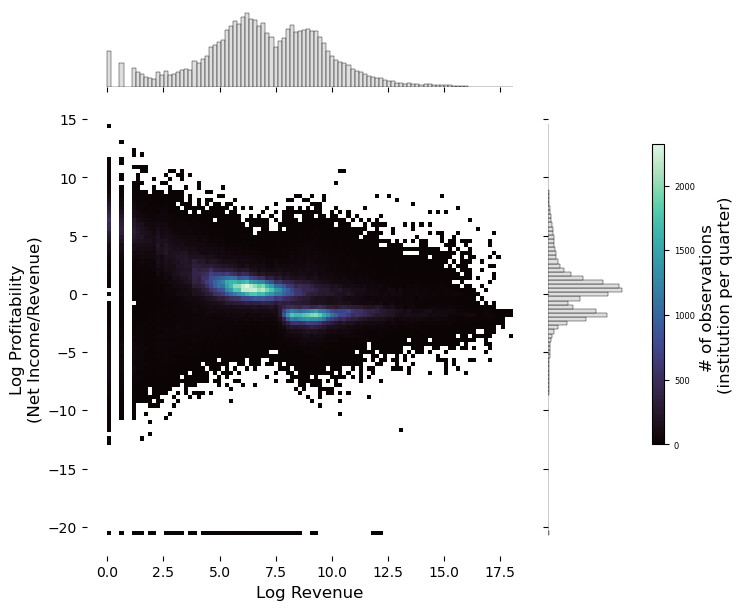

In [7]:
figure_path_ = "../outputs/distribution_revenue_profitability_all.png"

joint = sns.jointplot(
    x=df_all[cond_positive_revenue]['REVENUE_logneg'].to_numpy(),
    y=df_all[cond_positive_revenue]['PROFITABILITY_logneg'].to_numpy(),
    kind="hist",
    bins=100,
    cmap="mako",
    marginal_kws=dict(bins=100, fill=True, color="#D3D3D3"),
)

joint.set_axis_labels(
    "Log Revenue", "Log Profitability\n(Net Income/Revenue)", fontsize=12
)

fig = joint.fig
cax = fig.add_axes([1.02, 0.25, 0.02, 0.5])  # [left, bottom, width, height]

cbar = plt.colorbar(joint.ax_joint.collections[0], cax=cax)
cbar.set_label("# of observations \n(institution per quarter)", fontsize=12)
cbar.ax.tick_params(labelsize=6)

# Remove spines from the main joint plot
for spine in joint.ax_joint.spines.values():
    spine.set_visible(False)

# Optionally, remove spines from the marginal histograms
for spine in joint.ax_marg_x.spines.values():
    spine.set_visible(False)
for spine in joint.ax_marg_y.spines.values():
    spine.set_visible(False)


plt.savefig(figure_path_, dpi=300, bbox_inches='tight')  # PNG with high resolution
plt.show()


### Distribution of Revenue and Profitability for 9C banks

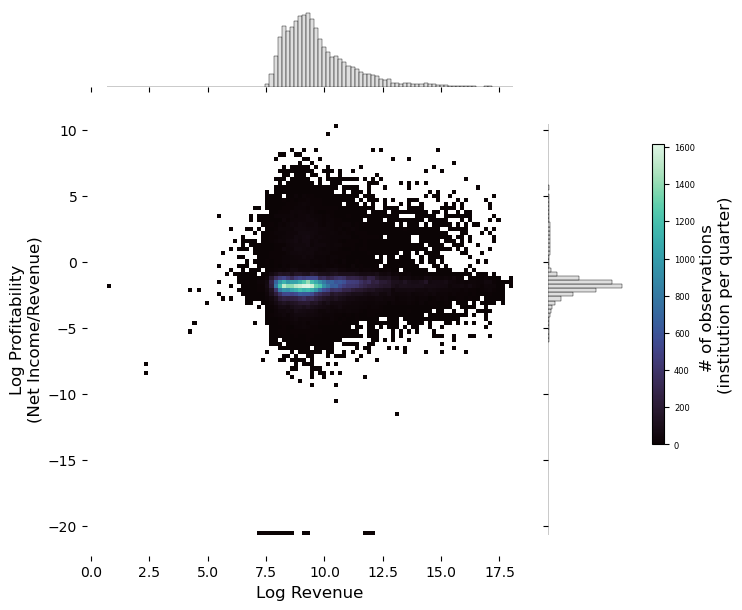

In [8]:
figure_path_ = "../outputs/distribution_revenue_profitability_9c.png"


joint = sns.jointplot(
    x=df_all[cond_y9c & cond_positive_revenue]['REVENUE_logneg'].to_numpy(),
    y=df_all[cond_y9c & cond_positive_revenue]['PROFITABILITY_logneg'].to_numpy(),
    kind="hist",
    bins=100,
    cmap="mako",
    marginal_kws=dict(bins=100, fill=True, color="#D3D3D3"),
)

joint.set_axis_labels(
    "Log Revenue", "Log Profitability\n(Net Income/Revenue)", fontsize=12
)

fig = joint.fig
cax = fig.add_axes([1.02, 0.25, 0.02, 0.5])  # [left, bottom, width, height]

cbar = plt.colorbar(joint.ax_joint.collections[0], cax=cax)
cbar.set_label("# of observations \n(institution per quarter)", fontsize=12)
cbar.ax.tick_params(labelsize=6)

# Remove spines from the main joint plot
for spine in joint.ax_joint.spines.values():
    spine.set_visible(False)

# Optionally, remove spines from the marginal histograms
for spine in joint.ax_marg_x.spines.values():
    spine.set_visible(False)
for spine in joint.ax_marg_y.spines.values():
    spine.set_visible(False)

plt.savefig(figure_path_, dpi=300, bbox_inches='tight')  # PNG with high resolution
plt.show()





### Overtime distribution of Revenue or Net Income for all 9C banks

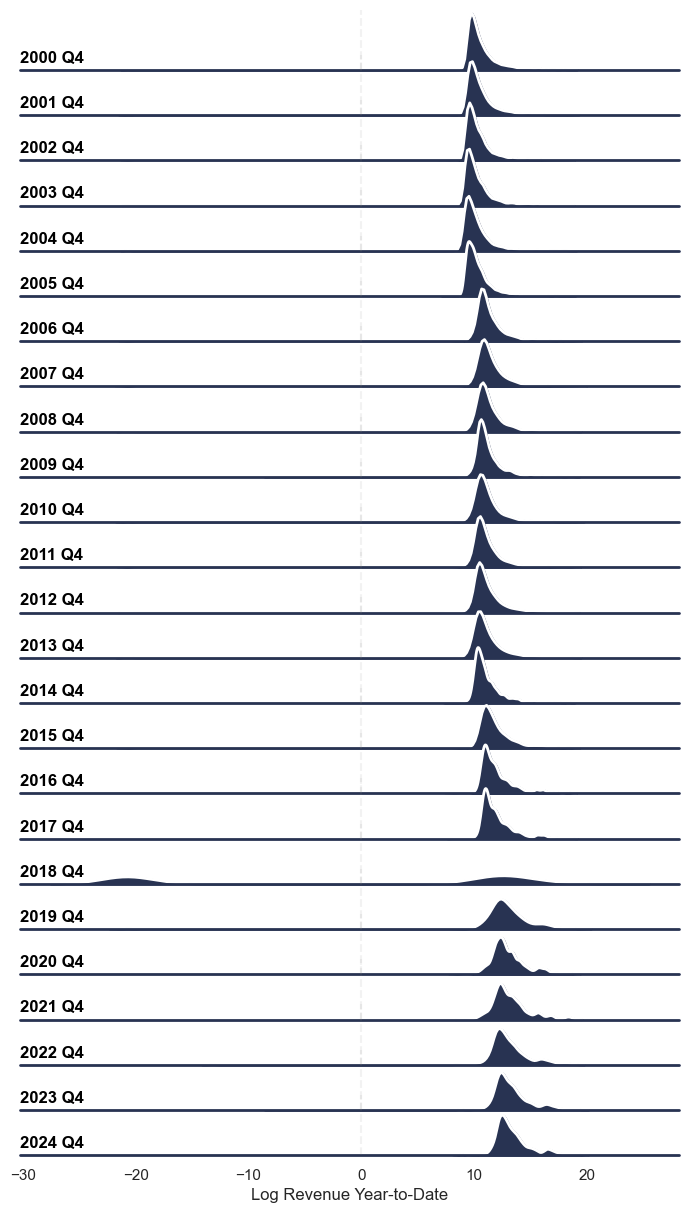

In [18]:
figure_path_ = '../outputs/overtime_distribution_netincome_9c.png'
col_xaxis = "NET_INCOME_CUMMULATIVE_logneg"
title_ = "Log Net Income Year-to-Date"
pal = sns.cubehelix_palette(1, rot=-.25, light=.7)

# uncomment for revenue plots (comment previous for net income plots)
figure_path_ = '../outputs/overtime_distribution_revenue_9c.png'
col_xaxis = "REVENUE_CUMMULATIVE_logneg"
title_ = "Log Revenue Year-to-Date"
pal = sns.cubehelix_palette(1, rot=-.25, light=.2)

col_yaxis = "quarter_code"


sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})



# Create the data
df = df_all[(df_all['report_type'].str.contains('Y9C')==True)
             & (df_all['quarter'].str.endswith('1231') == True) #SINCE WE ARE USING REVENUE_CUMMULATIVE_logneg THERE IS NO ISSUE
            #  & (df_all['year'].isin(range(2008,2014)) )
            ]
            


# Initialize the FacetGrid object

g = sns.FacetGrid(df, row=col_yaxis, hue=col_yaxis, aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, col_xaxis,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, col_xaxis, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color='black',
            ha="left", va="center", transform=ax.transAxes)


g.map(label, col_xaxis)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

bottom_ax = g.axes[-1, 0]

bottom_ax.set_xlabel(title_)  # ← change text here

# Add vertical line to each subplot inside the FacetGrid
for ax in g.axes.flat:
    ax.axvline(
        x=0,
        color='grey',
        linestyle='--',
        alpha=0.1,
    )


plt.savefig(figure_path_, dpi=300, bbox_inches='tight')  # PNG with high resolution
plt.show()




### Evolution of Mean and IQR for Revenue and Net Income for all 9C banks

In [15]:
figure_path_ = '../outputs/overtime_rev_netincome_iqr_mean_crisis.png'
cond_to_consider = True 

# uncomment to have variations when filtering for companies with positive net income
figure_path_ = '../outputs/overtime_rev_netincome_iqr_mean_crisis_positive_netincome.png'
cond_to_consider = cond_positive_net_income


In [16]:
quarters_all = df_all['quarter_code'].unique()
IQRs_netincome, IQRs_revenue = {}, {}
mean_netincome, mean_revenue = {}, {}

top_percentile = 75
bottom_percentile = 25

for quarter_ in quarters_all:
    data = df_all[(df_all['quarter_code'] == quarter_) 
                  & cond_to_consider
                  & (df_all['report_type'].str.contains('Y9C')==True)
                  ]
    data_netincome = data['NET_INCOME'].apply(log_neg).values
    data_revenue = data['REVENUE'].apply(log_neg).values
    IQR_netincome = np.percentile(data_netincome,top_percentile) - np.percentile(data_netincome,bottom_percentile)
    IQR_revenue = np.percentile(data_revenue,top_percentile) - np.percentile(data_revenue,bottom_percentile)
    IQRs_netincome[quarter_] = IQR_netincome
    IQRs_revenue[quarter_] = IQR_revenue

    mean_netincome[quarter_] = data_netincome.mean()
    mean_revenue[quarter_] = data_revenue.mean()
    

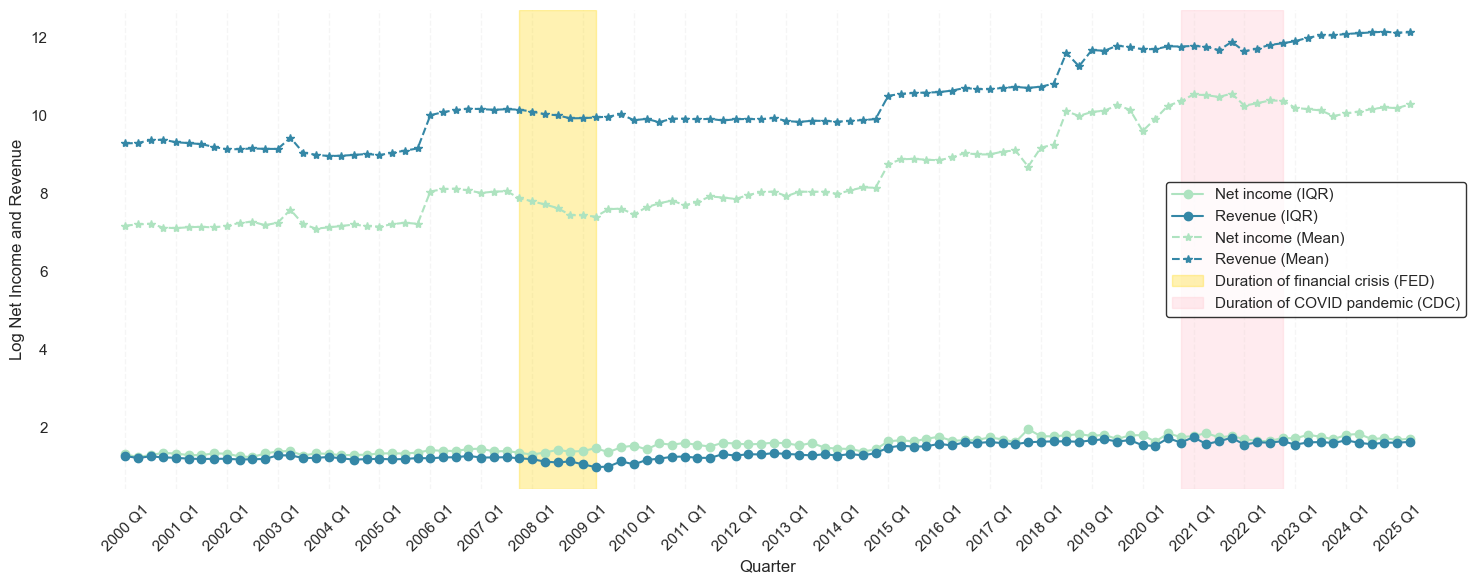

In [17]:
quarters = sorted(IQRs_netincome.keys())
iqr_values_netincome = [IQRs_netincome[q] for q in quarters]
iqr_values_revenue = [IQRs_revenue[q] for q in quarters]

mean_values_netincome = [mean_netincome[q] for q in quarters]
mean_values_revenue = [mean_revenue[q] for q in quarters]

revenue_color = sns.color_palette("mako", 10)[5]
net_income_color = sns.color_palette("mako", 10)[-1]
covid_color = 'pink'
financial_crisis_color = 'gold'


plt.figure(figsize=(15,6))
plt.plot(quarters, iqr_values_netincome, label ='Net income (IQR)', color = net_income_color, marker='o')
plt.plot(quarters, iqr_values_revenue, color=revenue_color, label ='Revenue (IQR)', marker='o')

plt.plot(quarters, mean_values_netincome, label ='Net income (Mean)', linestyle='--' , color = net_income_color , marker='*' )
plt.plot(quarters, mean_values_revenue, color=revenue_color, label ='Revenue (Mean)', linestyle='--', marker='*')

q1_ticks = [q for q in quarters if q.endswith("Q1")]  # or q[-2:] == "Q1"
plt.xticks(q1_ticks, rotation=45)


#Define financial crisis period
start = "2007 Q4"
end   = "2009 Q2"

start_idx = quarters.index(start)
end_idx   = quarters.index(end)

plt.axvspan(start_idx, end_idx, color=financial_crisis_color, alpha=0.3, label = 'Duration of financial crisis (FED)')

#Define financial crisis period
start = "2020 Q4"
end   = "2022 Q4"

start_idx = quarters.index(start)
end_idx   = quarters.index(end)

plt.axvspan(start_idx, end_idx, color=covid_color , alpha=0.3, label = 'Duration of COVID pandemic (CDC)')   # pink area


plt.xlabel("Quarter")
plt.ylabel("Log Net Income and Revenue")
# plt.title("IQR over Time")
plt.grid(axis='x', color='grey', alpha=0.075, linestyle='--', linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
leg = plt.legend()
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('black')   # optional

ax = plt.gca()
for idx,spine in enumerate(ax.spines.values()):
    spine.set_visible(False)

plt.savefig(figure_path_, dpi=300, bbox_inches='tight')  # PNG with high resolution
plt.show()



### Previous figure not used

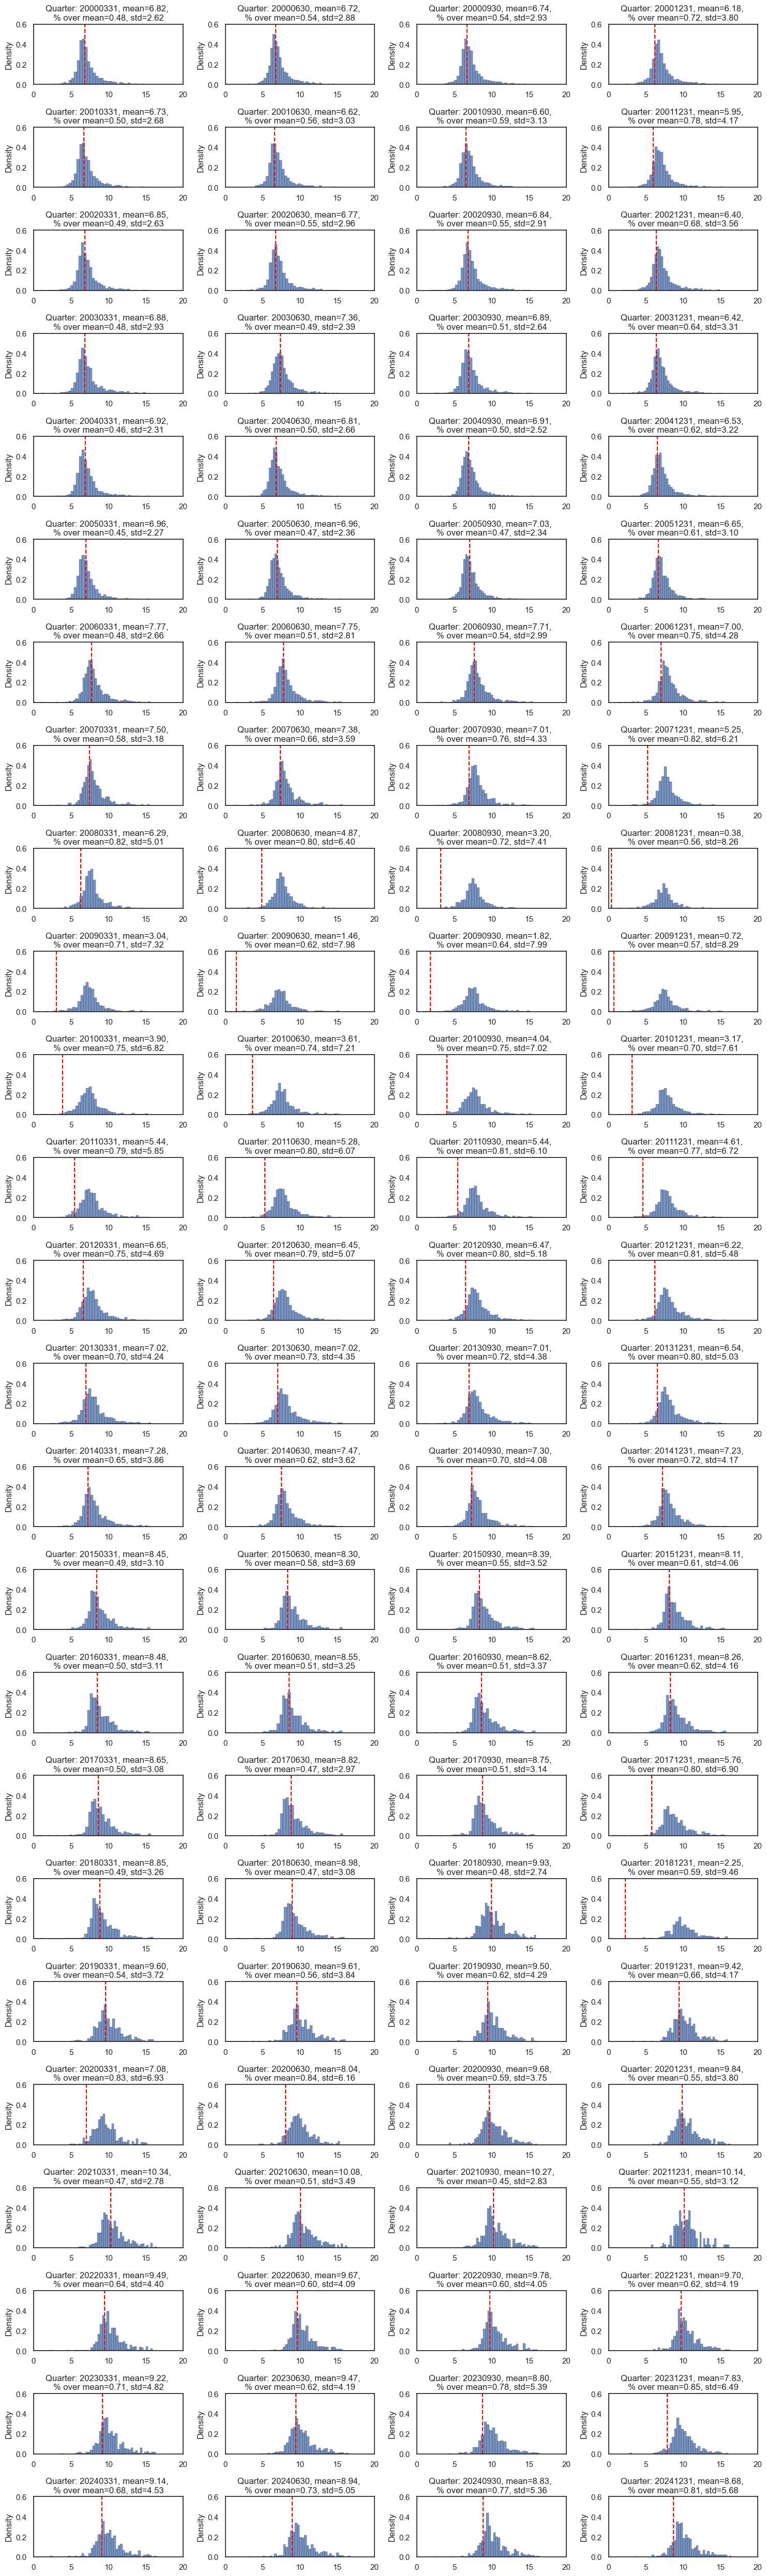

In [14]:

# quarters_all = df_all[df_all['year'].isin([2006,2007,2008,2009,2010])]['quarter'].unique()
# quarters_all = df_all[df_all['year'].isin([2011,2012,2013,2014,2015])]['quarter'].unique()
# quarters_all = df_all[df_all['year'].isin([2016,2017,2018,2019,2020])]['quarter'].unique()
# quarters_all = df_all[df_all['month'].isin([6,12])]['quarter'].unique()
quarters_all = df_all['quarter'].unique()
figure, axes = plt.subplots(nrows=len(quarters_all)//4, ncols=4, figsize=(15,50))
for quarter_,ax in zip(quarters_all, axes.flatten()):
    data = df_all[(df_all['quarter'] == quarter_) 
                  & (df_all['REVENUE'] != 0) 
                  & (df_all['report_type'].str.contains('Y9SP')==False)
                  ]['NET_INCOME'].apply(log_neg).values
    sns.histplot(data, bins=100, kde=False, stat='density', edgecolor='black', label='Data', ax=ax)
    ax.vlines(data.mean(), 0, 0.6, color='red', linestyle='--', label='Fitted Mean')
    ax.set_title(f'Quarter: {quarter_}, mean={data.mean():.2f}, \n% over mean={data[data>data.mean()].shape[0]/data.shape[0]:.2f}, std={data.std():.2f}')
    ax.set_xlim(0,20)
    ax.set_ylim(0,0.6)
plt.tight_layout()